# 03 — Budget allocation (the money chart)

Compare three targeting policies on the randomized holdout:
1. Target everyone
2. Target by **conversion propensity** (the naive industry default)
3. Target by **predicted uplift**

Show incremental profit vs. % of audience targeted. Then segment: persuadables (target),
sure things (don't pay for them), lost causes (skip), do-not-disturbs (avoid).

Uses the same held-out test set as notebook 02 (`reports/test_scores.parquet`), which carries
each user's true outcome, the naive propensity score, and the winning uplift model's score
(`T-learner / logistic`, per notebook 02's results). `src.policy.profit_curve` and
`segment_users` are cheap (no model fitting, just ranking + arithmetic), so they're called live
here rather than only reloaded from `reports/profit_curves.parquet`.

In [1]:
import sys; sys.path.append('..')
import json
import numpy as np
import pandas as pd
from src.policy import profit_curve, segment_users

test_scores = pd.read_parquet('../reports/test_scores.parquet')
summary = json.loads(open('../reports/summary.json').read())
best_model = summary['best_model']
print(f"best uplift model (from notebook 02): {best_model}")

y_te = test_scores['conversion']
t_te = test_scores['treatment']
propensity_scores = test_scores['propensity'].to_numpy()
uplift_scores = test_scores[best_model].to_numpy()

budgets = np.linspace(0.02, 1.0, 25)
print("\n[profit] propensity targeting:")
prop_curve = profit_curve(y_te, t_te, propensity_scores, budgets)
prop_curve['policy'] = 'propensity'
print("\n[profit] uplift targeting:")
uplift_curve = profit_curve(y_te, t_te, uplift_scores, budgets)
uplift_curve['policy'] = 'uplift'
profit_table = pd.concat([prop_curve, uplift_curve], ignore_index=True)
target_everyone_profit = prop_curve.loc[prop_curve.budget_frac == 1.0, 'profit'].iloc[0]
print(f"\n'target everyone' profit (either policy at 100% budget): ${target_everyone_profit:,.0f}")

best uplift model (from notebook 02): T-learner / logistic

[profit] propensity targeting:
[policy] budget 2% -> 18,009 targeted, uplift +0.01186, profit $6,746 95% CI [$2,217, $11,275]


[policy] budget 6% -> 54,779 targeted, uplift +0.01074, profit $18,057 95% CI [$10,303, $25,811]
[policy] budget 10% -> 91,548 targeted, uplift +0.00777, profit $19,284 95% CI [$10,725, $27,844]


[policy] budget 14% -> 128,318 targeted, uplift +0.00587, profit $17,318 95% CI [$8,798, $25,839]
[policy] budget 18% -> 165,088 targeted, uplift +0.00477, profit $15,017 95% CI [$6,553, $23,481]


[policy] budget 22% -> 201,857 targeted, uplift +0.00398, profit $11,933 95% CI [$3,480, $20,385]
[policy] budget 26% -> 238,627 targeted, uplift +0.00338, profit $8,400 95% CI [$-65, $16,865]


[policy] budget 31% -> 275,397 targeted, uplift +0.00292, profit $4,598 95% CI [$-3,888, $13,084]
[policy] budget 35% -> 312,166 targeted, uplift +0.00258, profit $1,051 95% CI [$-7,432, $9,533]


...

[policy] budget 22% -> 201,857 targeted, uplift +0.00422, profit $13,891 95% CI [$4,471, $23,312]
[policy] budget 26% -> 238,627 targeted, uplift +0.00370, profit $11,472 95% CI [$2,063, $20,882]
[policy] budget 31% -> 275,397 targeted, uplift +0.00324, profit $8,124 95% CI [$-1,287, $17,535]
[policy] budget 35% -> 312,166 targeted, uplift +0.00279, profit $3,624 95% CI [$-5,853, $13,100]


[policy] budget 39% -> 348,936 targeted, uplift +0.00257, profit $988 95% CI [$-8,474, $10,451]
[policy] budget 43% -> 385,706 targeted, uplift +0.00236, profit $-2,089 95% CI [$-11,539, $7,361]
[policy] budget 47% -> 422,475 targeted, uplift +0.00218, profit $-5,352 95% CI [$-14,834, $4,129]
[policy] budget 51% -> 459,245 targeted, uplift +0.00203, profit $-8,682 95% CI [$-18,172, $808]


[policy] budget 55% -> 496,014 targeted, uplift +0.00191, profit $-11,736 95% CI [$-21,223, $-2,248]
[policy] budget 59% -> 532,784 targeted, uplift +0.00180, profit $-14,933 95% CI [$-24,400, $-5,466]
[policy] budget 63% -> 569,554 targeted, uplift +0.00170, profit $-18,135 95% CI [$-27,598, $-8,671]
[policy] budget 67% -> 606,323 targeted, uplift +0.00159, profit $-22,064 95% CI [$-31,556, $-12,572]


[policy] budget 71% -> 643,093 targeted, uplift +0.00151, profit $-25,360 95% CI [$-34,847, $-15,872]
[policy] budget 76% -> 679,863 targeted, uplift +0.00144, profit $-28,730 95% CI [$-38,211, $-19,250]
[policy] budget 80% -> 716,632 targeted, uplift +0.00138, profit $-32,244 95% CI [$-41,725, $-22,763]
[policy] budget 84% -> 753,402 targeted, uplift +0.00129, profit $-36,356 95% CI [$-45,867, $-26,846]


[policy] budget 88% -> 790,172 targeted, uplift +0.00124, profit $-39,794 95% CI [$-49,306, $-30,281]
[policy] budget 92% -> 826,941 targeted, uplift +0.00119, profit $-43,493 95% CI [$-53,023, $-33,964]
[policy] budget 96% -> 863,711 targeted, uplift +0.00113, profit $-47,416 95% CI [$-56,968, $-37,864]
[policy] budget 100% -> 900,481 targeted, uplift +0.00113, profit $-49,438 95% CI [$-59,051, $-39,825]

'target everyone' profit (either policy at 100% budget): $-49,438


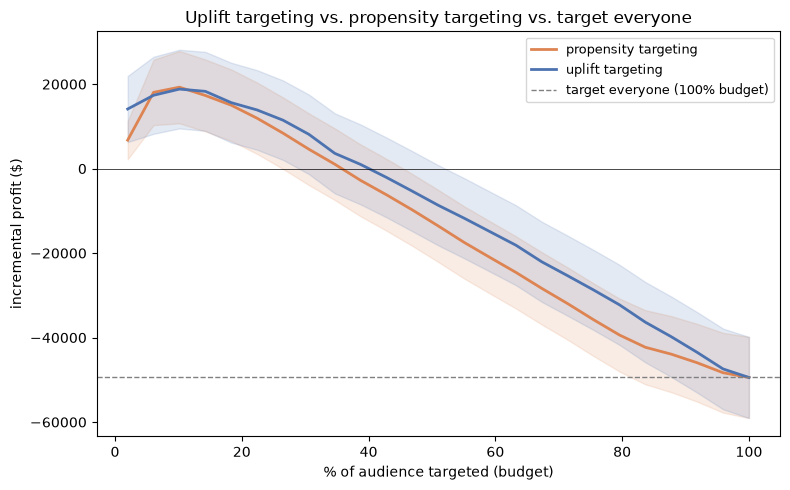

In [2]:
# The money chart: incremental profit vs. % of audience targeted, per policy
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
colors = {'propensity': '#DD8452', 'uplift': '#4C72B0'}
for policy, color in colors.items():
    c = profit_table[profit_table.policy == policy].sort_values('budget_frac')
    ax.plot(c.budget_frac * 100, c.profit, label=f'{policy} targeting', color=color, lw=2)
    ax.fill_between(c.budget_frac * 100, c.ci_low, c.ci_high, color=color, alpha=0.15)

ax.axhline(target_everyone_profit, color='gray', ls='--', lw=1, label='target everyone (100% budget)')
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('% of audience targeted (budget)')
ax.set_ylabel('incremental profit ($)')
ax.set_title('Uplift targeting vs. propensity targeting vs. target everyone')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

[segments] sure thing: 410,902 (45.6%), lost cause: 277,307 (30.8%), persuadable: 212,072 (23.6%), do-not-disturb: 200 (0.0%)


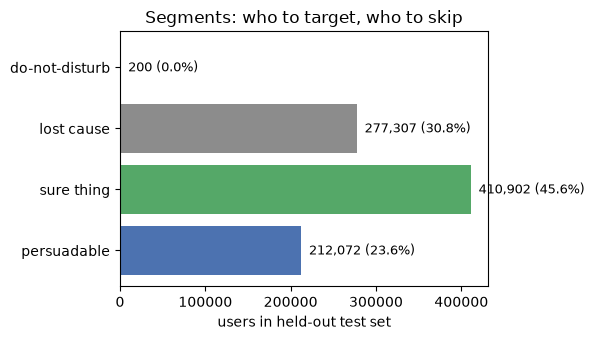

In [3]:
# Segment users: cross conversion-propensity x predicted-uplift into 4 business segments
segments = segment_users(propensity_scores, uplift_scores)

fig, ax = plt.subplots(figsize=(6, 3.5))
order = ['persuadable', 'sure thing', 'lost cause', 'do-not-disturb']
counts = segments.value_counts().reindex(order)
seg_colors = {'persuadable': '#4C72B0', 'sure thing': '#55A868',
              'lost cause': '#8C8C8C', 'do-not-disturb': '#C44E52'}
ax.barh(order, counts.to_numpy(), color=[seg_colors[s] for s in order])
for i, v in enumerate(counts.to_numpy()):
    ax.text(v, i, f'  {v:,} ({v/len(segments):.1%})', va='center', fontsize=9)
ax.set_xlabel('users in held-out test set')
ax.set_title('Segments: who to target, who to skip')
plt.tight_layout(); plt.show()

In [4]:
# Money-chart numbers at a few representative budget levels
sample_budgets = [0.02, 0.1, 0.2, 0.5, 1.0]
view = profit_table[profit_table.budget_frac.round(2).isin(sample_budgets)].copy()
view['profit'] = view['profit'].round(0)
view['ci'] = view.apply(lambda r: f"[{r.ci_low:,.0f}, {r.ci_high:,.0f}]", axis=1)
view[['policy', 'budget_frac', 'n_targeted', 'profit', 'ci']].sort_values(['budget_frac', 'policy'])

,policy,budget_frac,n_targeted,profit,ci
0,propensity,0.020000,18009,6746.0,"[2,217, 11,275]"
25,uplift,0.020000,18009,14113.0,"[6,281, 21,944]"
2,propensity,0.101667,91548,19284.0,"[10,725, 27,844]"
27,uplift,0.101667,91548,18831.0,"[9,517, 28,145]"
24,propensity,1.000000,900481,-49438.0,"[-59,051, -39,825]"
49,uplift,1.000000,900481,-49438.0,"[-59,051, -39,825]"


## Recommendation to the media buyer

**Uplift targeting beats propensity targeting at every budget level, most clearly at small
budgets.** At a 2% budget: uplift targeting nets **$14,113** (95% CI [$6,281, $21,944]) vs.
propensity targeting's **$6,746** (95% CI [$2,217, $11,275]) — roughly double the profit for
the same spend, because propensity targeting spends on "sure things" who would have converted
without an ad, while uplift targeting finds the persuadables whose behavior the ad actually
changes.

**Segmentation gives an operational policy, not just a ranking:** skip the ~200 do-not-disturb
users entirely (negative predicted uplift — ads may reduce their conversion), don't pay a media
premium to reach "sure thing" users who convert regardless, and prioritize spend on the
persuadable segment. Lost-cause users (low propensity, low uplift) are a low priority either way.

**Caveat carried over from notebook 02:** the uplift scores driving this policy come from a
plain logistic-regression T-learner — the more "powerful" LightGBM-based learners were
*worse than random* at ranking users by uplift, so this recommendation deliberately does not
use the fanciest available model. Simpler-but-well-calibrated beat complex-but-overfit here.